In [3]:
%pip install matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:

df = pd.read_csv('churn-bigml-80.csv')
df1 = pd.read_csv('churn-bigml-20.csv')

In [5]:
def preprocess(df):
  df.columns = df.columns.str.lower().str.replace(' ', '_')
  if 'churn' in df.columns:
    df['churn'] = df.churn.map({False:0, True:1})
  df['total_calls'] = df['total_day_calls'] + df['total_eve_calls'] + df['total_night_calls'] + df['total_intl_calls']
  df['total_minutes'] = df['total_day_minutes'] + df['total_eve_minutes'] + df['total_night_minutes'] + df['total_intl_minutes']
  df['avg_call_duration'] = df['total_minutes'] / (df['total_calls'].replace(0,1))
  df['high_service_calls'] = (df['customer_service_calls'] > 3).astype(int)
  df['total_charge'] = df['total_day_charge'] + df['total_eve_charge'] + df['total_night_charge'] + df['total_intl_charge']
  df.drop(['total_day_minutes', 'total_eve_minutes', 'total_night_minutes', 'total_intl_minutes', 'total_minutes','total_eve_charge','total_day_charge'], axis= 1 , inplace= True)
  df.drop(["total_eve_calls", "total_night_calls", "total_calls", 'total_day_calls', "avg_call_duration", "area_code", "state" ], inplace= True, axis= 1)
  df['international_plan'] = df['international_plan'].map({'Yes': 1, 'No': 0})
  df['voice_mail_plan'] = df['voice_mail_plan'].map({'Yes': 1, 'No': 0})


  return df

In [6]:
df=preprocess(df)
df1=preprocess(df1)

In [7]:
df1.shape


(667, 11)

In [8]:
!pip install category_encoders
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder , RobustScaler , StandardScaler , OrdinalEncoder , LabelEncoder
from category_encoders.binary import BinaryEncoder
from sklearn.model_selection import GridSearchCV, KFold, cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, recall_score, accuracy_score, precision_score, f1_score, confusion_matrix, classification_report
from imblearn.combine import SMOTETomek

  Using cached category_encoders-2.9.0-py3-none-any.whl.metadata (7.9 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
Using cached category_encoders-2.9.0-py3-none-any.whl (85 kB)
Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.5 MB 10.2 MB/s eta 0:00:01
   -------------- ------------------------- 3.4/9.5 MB 9.7 MB/s eta 0:00:01
   ----------------------- ---------------- 5.5/9.5 MB 10.0 MB/s eta 0:00:01
   ------------------------------- -------- 7.6/9.5 MB 10.1 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 10.1 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 9.9 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
X=df.drop('churn',axis=1)
y=df['churn']
X_test=df1.drop('churn',axis=1)
y_test=df1['churn']

In [10]:
X.columns

Index(['account_length', 'international_plan', 'voice_mail_plan',
       'number_vmail_messages', 'total_night_charge', 'total_intl_calls',
       'total_intl_charge', 'customer_service_calls', 'high_service_calls',
       'total_charge'],
      dtype='object')

In [11]:
cat_columns = [ "voice_mail_plan", "international_plan" ]

num_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

if 'churn' in num_columns:
    num_columns.remove('churn')

In [12]:
# checking every models and its performnce

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [13]:
models = [
        ("DT", DecisionTreeClassifier()) ,
        ("RF", RandomForestClassifier()),
        ("XGB", XGBClassifier()),
        ("SVM", SVC()),
        ("KNN", KNeighborsClassifier()),
]

In [14]:

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

In [15]:
# handling imbalancing data

from collections import Counter

print("Before:", Counter(y))
X_res, y_res = SMOTETomek(smote=SMOTE(sampling_strategy={1: 1820}, random_state=24)).fit_resample(X,y)
print("After SMOTETomek:", Counter(y_res))


Before: Counter({0: 2278, 1: 388})
After SMOTETomek: Counter({0: 2225, 1: 1767})


In [16]:
# scoring metrics for evaluation

scoring = {
    'recall': make_scorer(recall_score),
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score),
    'f1': make_scorer(f1_score)
}
preprocessor = ColumnTransformer(
    transformers=[
        ('cat',  OrdinalEncoder(), cat_columns),
        ('num_scaling', RobustScaler(), num_columns )
    ],
    remainder='passthrough'
)

In [17]:
# ml pipeline for model selection

for model in models:
    # Build pipeline with preprocessing, SMOTETomek, and the model
    steps = [
   ('preprocessing', preprocessor),
   ("SmoteTomek", SMOTETomek(smote=SMOTE(sampling_strategy={1: 1820}, random_state=24))),
   (model)
]

    pipeline = Pipeline(steps= steps)  # Apply all pipeline steps and saved to use in CV

     # Cross-validation
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=21)
    result = cross_validate(pipeline, X_res, y_res, cv= skf, scoring= scoring, return_train_score= True)

    # Average recall
    print(f"{model[0]} Average Train Recall: {result['train_recall'].mean():.4f}")
    print(f"{model[0]} Average Test Recall: {result['test_recall'].mean():.4f}")

    # Average accuracy
    print(f"{model[0]} Average Train Accuracy: {result['train_accuracy'].mean():.4f}")
    print(f"{model[0]} Average Test Accuracy: {result['test_accuracy'].mean():.4f}")

    # Average precision
    print(f"{model[0]} Average Train Precision: {result['train_precision'].mean():.4f}")
    print(f"{model[0]} Average Test Precision: {result['test_precision'].mean():.4f}\n")

DT Average Train Recall: 0.9785
DT Average Test Recall: 0.8642
DT Average Train Accuracy: 0.9857
DT Average Test Accuracy: 0.8690
DT Average Train Precision: 0.9891
DT Average Test Precision: 0.8437

RF Average Train Recall: 0.9724
RF Average Test Recall: 0.8444
RF Average Train Accuracy: 0.9857
RF Average Test Accuracy: 0.9166
RF Average Train Precision: 0.9952
RF Average Test Precision: 0.9627

XGB Average Train Recall: 0.9782
XGB Average Test Recall: 0.8614
XGB Average Train Accuracy: 0.9868
XGB Average Test Accuracy: 0.9118
XGB Average Train Precision: 0.9920
XGB Average Test Precision: 0.9343

SVM Average Train Recall: 0.7305
SVM Average Test Recall: 0.7170
SVM Average Train Accuracy: 0.7489
SVM Average Test Accuracy: 0.7402
SVM Average Train Precision: 0.7104
SVM Average Test Precision: 0.7025

KNN Average Train Recall: 0.9321
KNN Average Test Recall: 0.8715
KNN Average Train Accuracy: 0.8924
KNN Average Test Accuracy: 0.8324
KNN Average Train Precision: 0.8419
KNN Average Test P

In [18]:
# chossing random forest as final model

# pipline with our final model
steps = [
     ('preprocessing', preprocessor),
     ("SmoteTomek", SMOTETomek(smote=SMOTE(sampling_strategy={1: 1820}, random_state=24))),
     ("RF" ,  RandomForestClassifier())
]

pipeline = Pipeline(steps= steps)

In [19]:
#handling Overfitting

param_grid = {
    'RF__n_estimators': [180, 200, 250], # No. of trees in the forest
    'RF__max_depth': [9 , 10,  11], # Maximum no of levels of the tree
    'RF__min_samples_split': [ 16 , 14 ,18], # min. no of samples required to split a node
    'RF__min_samples_leaf': [2, 4, 6] # min. no of samples required at each leaf node
}

scorers = {
    'recall': make_scorer(recall_score),
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score)
}

# Cross validation + GridSearchCV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=21)
grid = GridSearchCV( estimator= pipeline, param_grid= param_grid, cv= skf, scoring= scorers, refit='recall',  return_train_score= True )


result = grid.fit(X_res, y_res)

In [20]:
print(
    # Acc
    f"Train Acc: {result.cv_results_['mean_train_accuracy'][result.best_index_]:.4f} | "
    f"Test Acc: {result.cv_results_['mean_test_accuracy'][result.best_index_]:.4f} | "

    # recall
    f"Train Recall: {result.cv_results_['mean_train_recall'][result.best_index_]:.4f} | "
    f"Test Recall: {result.cv_results_['mean_test_recall'][result.best_index_]:.4f} | "

      # Precision
    f"Train Precision: {result.cv_results_['mean_train_precision'][result.best_index_]:.4f} | "
    f"Test Precision: {result.cv_results_['mean_test_precision'][result.best_index_]:.4f}"
)

Train Acc: 0.9168 | Test Acc: 0.8890 | Train Recall: 0.8224 | Test Recall: 0.7748 | Train Precision: 0.9877 | Test Precision: 0.9682


In [21]:
pipeline.set_params(**result.best_params_)

,steps,"[('preprocessing', ...), ('SmoteTomek', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num_scaling', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string read

In [22]:
Final_Model = pipeline.fit(X_res, y_res)

In [23]:
y_pred =Final_Model.predict(X_test)

# 6. EVALUATION METRICS
acc = accuracy_score(y_test, y_pred)
print(f"\n Model Accuracy: {acc:.2%}")
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred))


 Model Accuracy: 97.60%

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       572
           1       0.95      0.87      0.91        95

    accuracy                           0.98       667
   macro avg       0.97      0.93      0.95       667
weighted avg       0.98      0.98      0.98       667



In [24]:
%pip install seaborn
import seaborn as sns

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


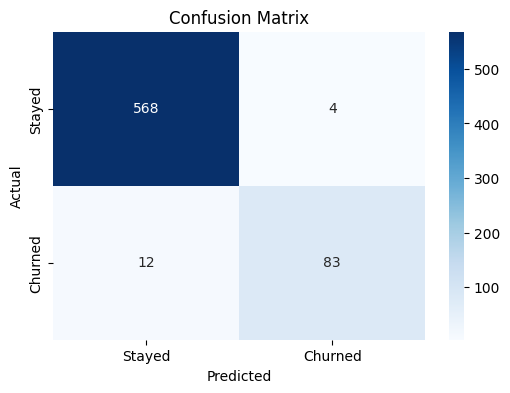

In [25]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Stayed', 'Churned'], yticklabels=['Stayed', 'Churned'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [26]:
import joblib
joblib.dump(Final_Model, "final_model.pkl")


['final_model.pkl']